## Explorando Dados com Pandas

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/guilhermeonrails/data-jobs/refs/heads/main/salaries.csv")

- Obs: os dados utilizados foram adaptados da plataforma Kaggle e disponibilizados pela Alura

In [5]:
df.head(10)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025.0,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M
1,2025.0,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M
2,2025.0,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M
3,2025.0,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M
4,2025.0,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M
5,2025.0,EN,FT,Data Engineer,80000,USD,80000,US,0,US,M
6,2025.0,SE,FT,Data Scientist,185000,USD,185000,US,0,US,M
7,2025.0,SE,FT,Data Scientist,148000,USD,148000,US,0,US,M
8,2025.0,MI,FT,Data Scientist,135000,USD,135000,CA,0,CA,M
9,2025.0,MI,FT,Data Scientist,108000,USD,108000,CA,0,CA,M


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133349 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   work_year           133339 non-null  float64
 1   experience_level    133349 non-null  object 
 2   employment_type     133349 non-null  object 
 3   job_title           133349 non-null  object 
 4   salary              133349 non-null  int64  
 5   salary_currency     133349 non-null  object 
 6   salary_in_usd       133349 non-null  int64  
 7   employee_residence  133349 non-null  object 
 8   remote_ratio        133349 non-null  int64  
 9   company_location    133349 non-null  object 
 10  company_size        133349 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 11.2+ MB


In [7]:
df.describe() # traz uma estatística descritiva, sem nenhum argumento só traz numéricos

,work_year,salary,salary_in_usd,remote_ratio
count,133339.000000,1.333490e+05,133349.000000,133349.000000
mean,2024.358770,1.632833e+05,157617.272098,20.905669
std,0.680627,2.173860e+05,74288.363097,40.590044
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.060200e+05,106000.000000,0.000000
50%,2024.000000,1.470000e+05,146206.000000,0.000000
75%,2025.000000,1.990000e+05,198000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


In [8]:
df.shape # (num_linhas, num_colunas)

(133349, 11)

In [9]:
linhas, colunas = df.shape[0], df.shape[1]
print("linhas:", linhas)
print("colunas:", colunas)

linhas: 133349
colunas: 11


In [10]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [11]:
# Dicionário de tradução das colunas
colunas_traduzidas = {
    'work_year': 'ano',
    'experience_level': 'senioridade',
    'employment_type': 'contrato',
    'job_title': 'cargo',
    'salary': 'salario',
    'salary_currency': 'moeda',
    'salary_in_usd': 'usd',
    'employee_residence': 'residencia',
    'remote_ratio': 'remoto',
    'company_location': 'local_empresa',
    'company_size': 'tamanho_empresa'
}

df = df.rename(columns=colunas_traduzidas)
df.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,local_empresa,tamanho_empresa
0,2025.0,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M
1,2025.0,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M
2,2025.0,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M
3,2025.0,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M
4,2025.0,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M


In [12]:
type(df)

pandas.core.frame.DataFrame

In [13]:
df.columns

Index(['ano', 'senioridade', 'contrato', 'cargo', 'salario', 'moeda', 'usd',
       'residencia', 'remoto', 'local_empresa', 'tamanho_empresa'],
      dtype='object')

### Contando variáveis categóricas

In [14]:
df["senioridade"].value_counts()

senioridade
SE    77241
MI    40465
EN    12443
EX     3200
Name: count, dtype: int64

In [15]:
df["contrato"].value_counts()

contrato
FT    132563
CT       394
PT       376
FL        16
Name: count, dtype: int64

In [16]:
df["remoto"].value_counts()

remoto
0      105312
100     27718
50        319
Name: count, dtype: int64

- 0 -> Presencial
- 100 -> Remoto
- 50 -> Híbrido

In [17]:
df["tamanho_empresa"].value_counts()


tamanho_empresa
M    129561
L      3574
S       214
Name: count, dtype: int64

### Renomeando as colunas categóricas

In [18]:
# Dicionário de tradução para as categorias de senioridade
senioridade = {
    'EN': 'Junior',
    'MI': 'Pleno',
    'SE': 'Senior',
    'EX': 'Executivo'
}

df['senioridade'] = df['senioridade'].replace(senioridade)
df['senioridade'].value_counts()

senioridade
Senior       77241
Pleno        40465
Junior       12443
Executivo     3200
Name: count, dtype: int64

In [19]:

contrato = {
    'FT': 'Tempo Integral',
    'PT': 'Tempo Parcial',
    'CT': 'Contrato',
    'FL': 'Freelance'
}

df['contrato'] = df['contrato'].replace(contrato)
df['contrato'].value_counts()

contrato
Tempo Integral    132563
Contrato             394
Tempo Parcial        376
Freelance             16
Name: count, dtype: int64

In [20]:
# Dicionário de tradução para as categorias de tamanho de empresa
tamanho_empresa = {
    'S': 'Pequena',
    'M': 'Média',
    'L': 'Grande'
}

df['tamanho_empresa'] = df['tamanho_empresa'].replace(tamanho_empresa)
df['tamanho_empresa'].value_counts()

tamanho_empresa
Média      129561
Grande       3574
Pequena       214
Name: count, dtype: int64

In [21]:
remoto = {
    0: 'Presencial',
    50: 'Híbrido',
    100: 'Remoto'
}

df['remoto'] = df['remoto'].replace(remoto)
df['remoto'].value_counts()

remoto
Presencial    105312
Remoto         27718
Híbrido          319
Name: count, dtype: int64

In [22]:
df.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,local_empresa,tamanho_empresa
0,2025.0,Senior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025.0,Senior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025.0,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025.0,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025.0,Junior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média


In [23]:
df.describe(include="object") # o 'freq' é o quanto o valor no 'top' é repetido

,senioridade,contrato,cargo,moeda,residencia,remoto,local_empresa,tamanho_empresa
count,133349,133349,133349,133349,133349,133349,133349,133349
unique,4,4,390,26,102,3,95,3
top,Senior,Tempo Integral,Data Scientist,USD,US,Presencial,US,Média
freq,77241,132563,17314,126140,119579,105312,119641,129561


In [24]:
df.describe()

,ano,salario,usd
count,133339.000000,1.333490e+05,133349.000000
mean,2024.358770,1.632833e+05,157617.272098
std,0.680627,2.173860e+05,74288.363097
min,2020.000000,1.400000e+04,15000.000000
25%,2024.000000,1.060200e+05,106000.000000
50%,2024.000000,1.470000e+05,146206.000000
75%,2025.000000,1.990000e+05,198000.000000
max,2025.000000,3.040000e+07,800000.000000


## Limpeza e Prepararação dos Dados

- Tratando valores nulos

In [25]:
df.isnull()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,local_empresa,tamanho_empresa
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
133344,False,False,False,False,False,False,False,False,False,False,False
133345,False,False,False,False,False,False,False,False,False,False,False
133346,False,False,False,False,False,False,False,False,False,False,False
133347,False,False,False,False,False,False,False,False,False,False,False


In [26]:
df.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,local_empresa,tamanho_empresa
0,2025.0,Senior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025.0,Senior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025.0,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025.0,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025.0,Junior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média


In [27]:
df.isnull().sum()

ano                10
senioridade         0
contrato            0
cargo               0
salario             0
moeda               0
usd                 0
residencia          0
remoto              0
local_empresa       0
tamanho_empresa     0
dtype: int64

Temos 10 pessoas que não tem a variável 'ano' preenchida

In [28]:
df['ano'].unique()

array([2025.,   nan, 2024., 2022., 2023., 2020., 2021.])

'nan' = not a number

In [29]:
df[df.isnull().any(axis=1)]

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,local_empresa,tamanho_empresa
5588,NaN,Senior,Tempo Integral,Product Manager,184500,USD,184500,US,Presencial,US,Média
59692,NaN,Pleno,Tempo Integral,Engineer,110000,USD,110000,DE,Presencial,DE,Média
59710,NaN,Junior,Tempo Integral,Data Scientist,208800,USD,208800,US,Presencial,US,Média
59759,NaN,Senior,Tempo Integral,Software Engineer,135000,USD,135000,US,Presencial,US,Média
59789,NaN,Senior,Tempo Integral,Engineer,112000,USD,112000,US,Presencial,US,Média
131000,NaN,Senior,Tempo Integral,Machine Learning Engineer,163800,USD,163800,US,Presencial,US,Média
131006,NaN,Senior,Tempo Integral,Data Analytics Manager,204500,USD,204500,US,Presencial,US,Média
133054,NaN,Junior,Tempo Integral,Data Scientist,40000,USD,40000,JP,Remoto,MY,Grande
133281,NaN,Pleno,Tempo Integral,Machine Learning Engineer,180000,PLN,46597,PL,Remoto,PL,Grande
133317,NaN,Pleno,Tempo Integral,Data Scientist,130000,USD,130000,US,Híbrido,US,Grande


In [30]:
import numpy as np

# Criação de um dataframe de teste para usar de exemplo
df_salarios = pd.DataFrame({
    'nome' : ['Ana', 'Bruno', 'Carlos', 'Daniele', 'Val'],
    'salario' : [4000, np.nan, 5000, np.nan, 100000]
})

# Calcula a media e substitui os nulos pela média e arredonda os valores
df_salarios['salario_media'] = df_salarios['salario'].fillna(df_salarios['salario'].mean().round(2))

'''Calcula a mediana e substitui os nulos pela mediana  -> não deixa os outliers influenciarem tanto a análise'''
df_salarios['salario_mediana'] = df_salarios['salario'].fillna(df_salarios['salario'].median())

df_salarios

,nome,salario,salario_media,salario_mediana
0,Ana,4000.0,4000.00,4000.0
1,Bruno,NaN,36333.33,5000.0
2,Carlos,5000.0,5000.00,5000.0
3,Daniele,NaN,36333.33,5000.0
4,Val,100000.0,100000.00,100000.0


- 3000
- 5000 -> essa é a mediana
- 100000

In [31]:
df_temperaturas = pd.DataFrame({
    'dia' : ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta'],
    'temperatura' : [30, np.nan, np.nan, 28, 27]
})

df_temperaturas

,dia,temperatura
0,Segunda,30.0
1,Terça,NaN
2,Quarta,NaN
3,Quinta,28.0
4,Sexta,27.0


In [32]:
# Preenchendo valores nulos com o método ffill (Forward Fill)
df_temperaturas['preenchido_ffill'] = df_temperaturas['temperatura'].ffill()

In [33]:
# com Back Fill (bfill)
df_temperaturas['preenchido_bfill'] = df_temperaturas['temperatura'].bfill()


In [34]:
df_temperaturas

,dia,temperatura,preenchido_ffill,preenchido_bfill
0,Segunda,30.0,30.0,30.0
1,Terça,NaN,30.0,28.0
2,Quarta,NaN,30.0,28.0
3,Quinta,28.0,28.0,28.0
4,Sexta,27.0,27.0,27.0


In [35]:
df_cidades = pd.DataFrame({
  'nome' : ['Ana', 'Bruno', 'Carlos', 'Daniele', 'Val'],
  'cidade' : ['São Paulo', np.nan, 'Curitiba', np.nan, 'Belém']  
})

df_cidades['cidade_preenchida'] = df_cidades['cidade'].fillna('Não Informado')

df_cidades

,nome,cidade,cidade_preenchida
0,Ana,São Paulo,São Paulo
1,Bruno,NaN,Não Informado
2,Carlos,Curitiba,Curitiba
3,Daniele,NaN,Não Informado
4,Val,Belém,Belém


Como nossa base df tem mais de 130000 linhas, remover 10 não vai impactar tanto em nossa análise, então vamos remover as linhas que possuem informações vazias e armazenar esse df numa variável chamada 'df_limpo'

In [36]:
df_limpo = df.dropna()

In [37]:
df_limpo.isnull().sum()

ano                0
senioridade        0
contrato           0
cargo              0
salario            0
moeda              0
usd                0
residencia         0
remoto             0
local_empresa      0
tamanho_empresa    0
dtype: int64

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133349 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ano              133339 non-null  float64
 1   senioridade      133349 non-null  object 
 2   contrato         133349 non-null  object 
 3   cargo            133349 non-null  object 
 4   salario          133349 non-null  int64  
 5   moeda            133349 non-null  object 
 6   usd              133349 non-null  int64  
 7   residencia       133349 non-null  object 
 8   remoto           133349 non-null  object 
 9   local_empresa    133349 non-null  object 
 10  tamanho_empresa  133349 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 11.2+ MB


In [39]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 133339 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ano              133339 non-null  float64
 1   senioridade      133339 non-null  object 
 2   contrato         133339 non-null  object 
 3   cargo            133339 non-null  object 
 4   salario          133339 non-null  int64  
 5   moeda            133339 non-null  object 
 6   usd              133339 non-null  int64  
 7   residencia       133339 non-null  object 
 8   remoto           133339 non-null  object 
 9   local_empresa    133339 non-null  object 
 10  tamanho_empresa  133339 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 12.2+ MB


In [40]:
df_limpo.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,local_empresa,tamanho_empresa
0,2025.0,Senior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025.0,Senior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025.0,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025.0,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025.0,Junior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média


In [41]:
df_limpo = df_limpo.assign(ano = df_limpo['ano'].astype('int64'))

In [42]:
df_limpo

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,local_empresa,tamanho_empresa
0,2025,Senior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025,Senior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025,Junior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média
...,...,...,...,...,...,...,...,...,...,...,...
133344,2020,Senior,Tempo Integral,Data Scientist,412000,USD,412000,US,Remoto,US,Grande
133345,2021,Pleno,Tempo Integral,Principal Data Scientist,151000,USD,151000,US,Remoto,US,Grande
133346,2020,Junior,Tempo Integral,Data Scientist,105000,USD,105000,US,Remoto,US,Pequena
133347,2020,Junior,Contrato,Business Data Analyst,100000,USD,100000,US,Remoto,US,Grande


## Visualização de Dados

In [43]:
df_limpo.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,local_empresa,tamanho_empresa
0,2025,Senior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025,Senior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025,Junior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média


In [44]:
df_limpo['senioridade'].value_counts()

senioridade
Senior       77236
Pleno        40462
Junior       12441
Executivo     3200
Name: count, dtype: int64

<Axes: title={'center': 'Distribuição de Senioridade'}, xlabel='senioridade'>

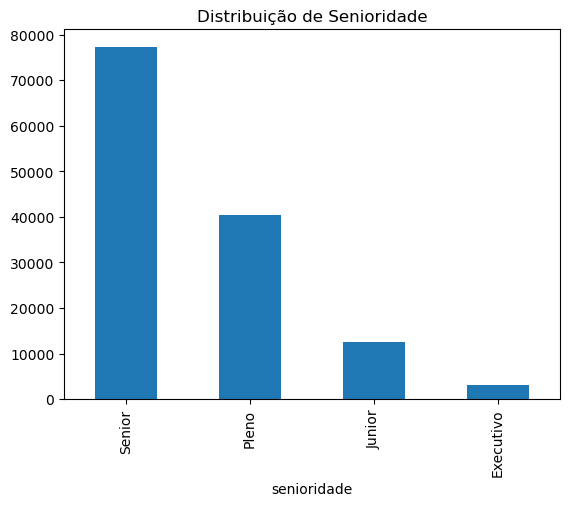

In [45]:
df_limpo['senioridade'].value_counts().plot(kind='bar', title='Distribuição de Senioridade')

In [46]:
type(df_limpo)

pandas.core.frame.DataFrame

In [47]:
import seaborn as sns

Vamos calcular o salário médio de cada cargo

<Axes: xlabel='senioridade', ylabel='usd'>

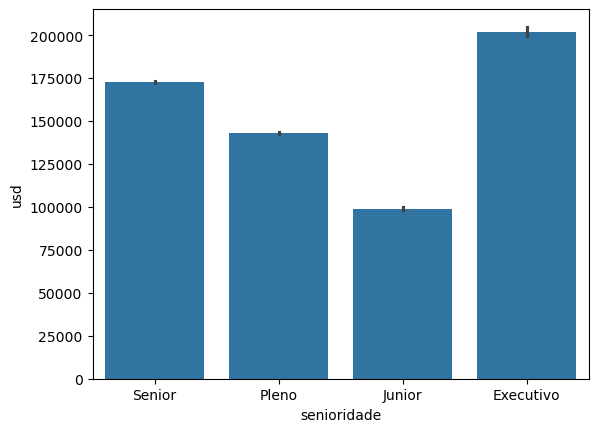

In [48]:
sns.barplot(data=df_limpo, x='senioridade', y='usd')

In [49]:
import matplotlib.pyplot as plt

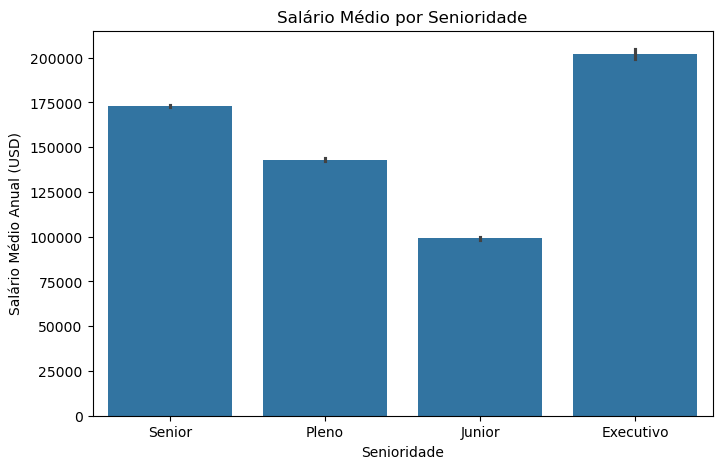

In [50]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_limpo, x='senioridade', y='usd')
plt.title('Salário Médio por Senioridade')
plt.xlabel('Senioridade')
plt.ylabel('Salário Médio Anual (USD)')
plt.show()

In [51]:
# Criando um ordenamento do maior para o menor. Se quiser ordenar ao contrário, só colocar TRUE
ordem = df_limpo.groupby('senioridade')['usd'].mean().sort_values(ascending=False).index
ordem

Index(['Executivo', 'Senior', 'Pleno', 'Junior'], dtype='object', name='senioridade')

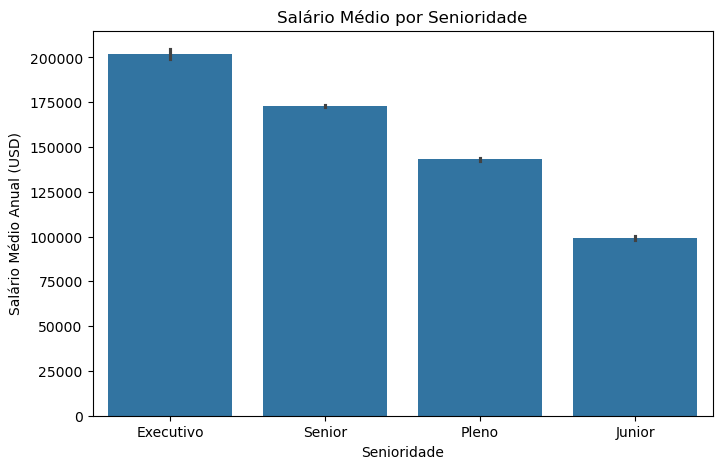

In [52]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_limpo, x='senioridade', y='usd', order=ordem)
plt.title('Salário Médio por Senioridade')
plt.xlabel('Senioridade')
plt.ylabel('Salário Médio Anual (USD)')
plt.show()

Agrupamos os salários da minha amostra por senioridade. Mas podemos também ver como está a distribuição de salários sem nenhum agrupamento, para ter uma visualização mais geral dessa variável na minha amostra... -> Usamos um histograma para isso.

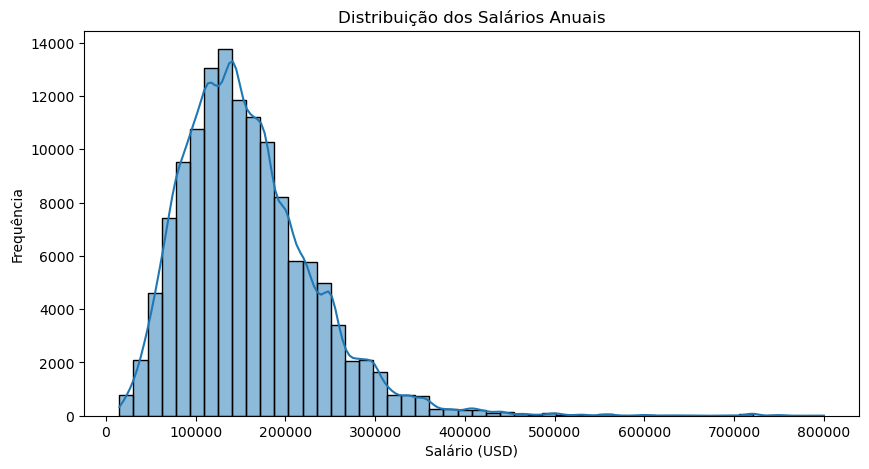

In [53]:
plt.figure(figsize=(10,5))
sns.histplot(df_limpo['usd'], bins=50, kde=True)
plt.title('Distribuição dos Salários Anuais')
plt.xlabel('Salário (USD)')
plt.ylabel('Frequência')
plt.show()

Percebemos que os valores de salário vão de 50,000 até 800,000 e a distribuição se concentra mais à esquerda (valores mais baixos). Essa não é uma distribuição do tipo Standard/Normal/Gaussiana (que ficaria concentrada mais no meio, ou seja, em torno de 375,000).
A maioria dos salários estão em torno 150,000.

a distribuição que se formou é chamada de distribuição assimétrica à direita (ou distribuição assimétrica positiva, skewed right, distribuição com cauda longa à direita).

Isso significa que:

A maior parte dos salários está concentrada em valores mais baixos (à esquerda do gráfico).
Existem poucos salários muito altos, que puxam a cauda da distribuição para a direita.
Esse tipo de distribuição é comum em dados de renda/salário, pois poucas pessoas ganham salários muito altos, enquanto a maioria ganha valores mais próximos do mínimo.

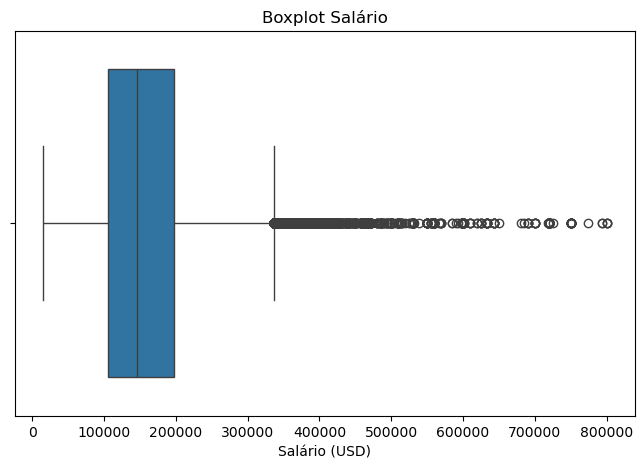

In [54]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_limpo['usd'])
plt.title('Boxplot Salário')
plt.xlabel('Salário (USD)')
plt.show()

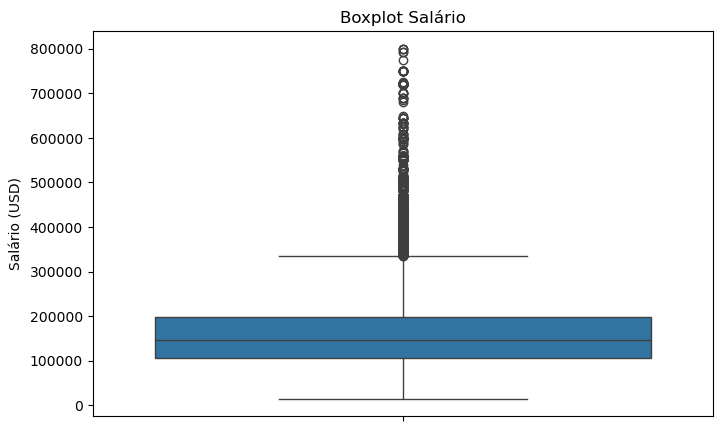

In [55]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df_limpo['usd'])
plt.title('Boxplot Salário')
plt.ylabel('Salário (USD)')
plt.show()

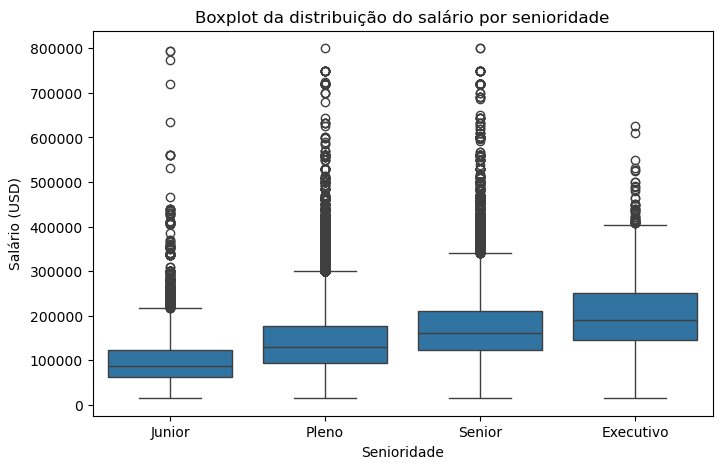

In [56]:
ordem_senioridade = ['Junior', 'Pleno', 'Senior', 'Executivo']

plt.figure(figsize=(8,5))
sns.boxplot(x='senioridade', y='usd', data=df_limpo, order=ordem_senioridade, )
plt.title('Boxplot da distribuição do salário por senioridade')
plt.ylabel('Salário (USD)')
plt.xlabel('Senioridade')
plt.show()

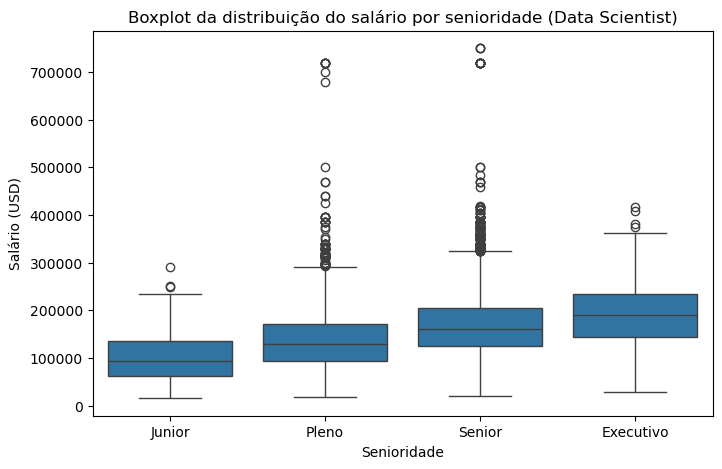

In [57]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='senioridade',
    y='usd',
    data=df_limpo[df_limpo['cargo'].str.contains('Data Scientist', case=False, na=False)],
    order=ordem_senioridade
)
plt.title('Boxplot da distribuição do salário por senioridade (Data Scientist)')
plt.ylabel('Salário (USD)')
plt.xlabel('Senioridade')
plt.show()

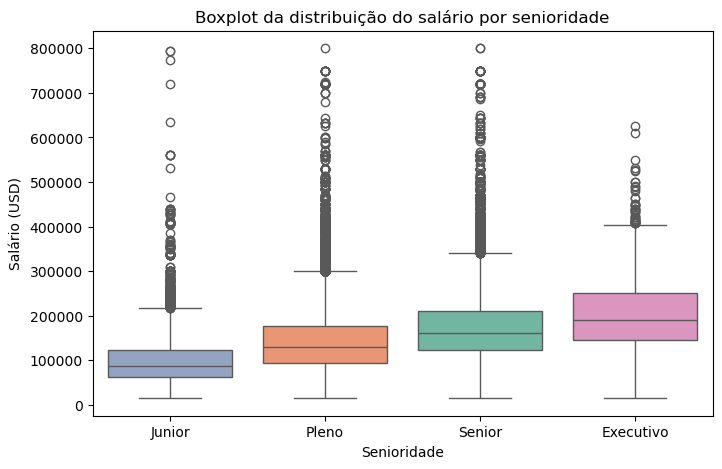

In [58]:
plt.figure(figsize=(8,5))
sns.boxplot(x='senioridade', y='usd', data=df_limpo, order=ordem_senioridade, palette='Set2', hue='senioridade')
plt.title('Boxplot da distribuição do salário por senioridade')
plt.ylabel('Salário (USD)')
plt.xlabel('Senioridade')
plt.show()

### Gráficos Interativos com Plotly

In [59]:
import plotly.express as px

In [60]:
import plotly.express as px

media_salarial = df_limpo.groupby('senioridade')['usd'].mean().sort_values(ascending=False).reset_index()

fig = px.bar(
    media_salarial,
    x='senioridade',
    y='usd',
    title='Média Salarial por Senioridade',
    labels={'usd': 'Salário Médio (USD)', 'senioridade': 'Senioridade'}
)
fig.show()

In [61]:
remoto_contagem = df_limpo['remoto'].value_counts().reset_index()
remoto_contagem.columns = ['tipo_trabalho', 'quantidade']

display(remoto_contagem)


,tipo_trabalho,quantidade
0,Presencial,105305
1,Remoto,27716
2,Híbrido,318


In [62]:
fig = px.pie(
    remoto_contagem,
    names='tipo_trabalho',
    values='quantidade',
    title='Proporção dos tipos de trabalho',
    hole=0.5
)

In [63]:
fig.update_traces(textinfo='percent+label')

fig.show()

### Desafio
- Criar um gráfico usando plotly que mostre a média salarial para o cargo de Data Scientist por país.

In [64]:
df_limpo['residencia'].value_counts()

residencia
US    119572
CA      5238
GB      3711
AU       517
NL       404
       ...  
KW         1
AS         1
CN         1
IQ         1
JE         1
Name: count, Length: 102, dtype: int64

In [65]:
pip install pycountry

Note: you may need to restart the kernel to use updated packages.


In [66]:
import pycountry

# Função para converter ISO-2 para ISO-3
def iso2_to_iso3(code):
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except:
        return None

# Criar nova coluna com código ISO-3
df_limpo['residencia_iso3'] = df_limpo['residencia'].apply(iso2_to_iso3)

df_ds = df_limpo[df_limpo['cargo'] == 'Data Scientist']
media_ds_pais = df_ds.groupby('residencia_iso3')['usd'].mean().reset_index()

media_ds_pais.head()

,residencia_iso3,usd
0,AND,50745.000000
1,ARG,42000.000000
2,AUS,112190.000000
3,AUT,50342.067797
4,BEL,66790.750000


In [67]:
# Gerar o mapa
fig = px.choropleth(
    media_ds_pais,
    locations='residencia_iso3',
    color='usd',
    color_continuous_scale='Blues',
    title='Salário médio de Cientista de Dados por país',
    labels={'usd': 'Salário médio (USD)', 'residencia_iso3':'País'}
)

fig.show()

In [68]:
df_limpo.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,local_empresa,tamanho_empresa,residencia_iso3
0,2025,Senior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média,USA
1,2025,Senior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média,USA
2,2025,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média,AUS
3,2025,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média,AUS
4,2025,Junior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média,USA


### Salvando o df tratado em csv

In [73]:
df_limpo.to_csv('dados-tratados.csv', index=False)

### Tentativa com o Copilot

In [70]:
# Filtra apenas os cargos de Data Scientist
df_ds = df_limpo[df_limpo['cargo'].str.contains('Data Scientist', case=False, na=False)]

# Calcula a média salarial por país de residência
media_pais = df_ds.groupby('residencia')['usd'].mean().reset_index()
# Ordena do maior para o menor salário médio
media_pais = media_pais.sort_values(by='usd', ascending=False)

media_pais.head()


,residencia,usd
52,US,162826.467181
9,CH,154315.142857
46,SG,152522.714286
6,BG,152500.000000
17,EG,140690.909091


In [71]:
# Cria o gráfico de barras
fig = px.bar(
    media_pais,
    x='residencia',
    y='usd',
    title='Média Salarial de Data Scientist por País',
    labels={'residencia': 'País de Residência', 'usd': 'Salário Médio (USD)'}
)
fig.show()